<a href="https://colab.research.google.com/github/nmwiley808/csci164/blob/main/project/csci164_Final_Project_Applied_Machine_Learning_w_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Machine Learning - Final Project

Course: CSCI 164 | Noah Wiley | Spring 2026

---

# Overview
This notebook walks through a complete machine learning workflow using Python and sckikit-learn across two real-world datasets

---

# Dataset 1 - Titanic Survival (Classification)
Using passenger data such such as age, sex, class, and fare. We can predict wheether a passenger survived. This is a binary classification problem.

# Dataset 2 - California Housing Prices (Regression)
Using census-level features like median income and location, we predict median house values. This is a regression problem.

---

# What to Expect
1. **Imports & Setup** – Load all necessary libraries
2. **Dataset 1: Titanic** – Load, explore, and preprocess the data
3. **Titanic Models** – Train Logistic Regression, Decision Tree, and k-NN
4. **Titanic Evaluation** – Confusion matrices, ROC curves, metrics comparison
5. **Titanic Tuning** – Optimize models using GridSearchCV
6. **Dataset 2: California Housing** – Load, explore, and preprocess the data
7. **Housing Models** – Train Linear Regression, Decision Tree, and k-NN
8. **Housing Evaluation** – Scatter plots, residual plots, metrics comparison
9. **Housing Tuning** – Optimize models using GridSearchCV
10. **Final Dashboard** – Side-by-side comparison of all models

---

# How to Run
Run each cell from top to bottom in order. All libraries are pre-installed in Google Colab.

In [4]:
# Setup

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


In [5]:
# Load Titanic via seaborn's built-in copy - no Kaggle Key needed
titanic_raw = sns.load_dataset('titanic')
print(titanic_raw.shape)
titanic_raw.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing values:
 survived         0
pclass           0
sex              0

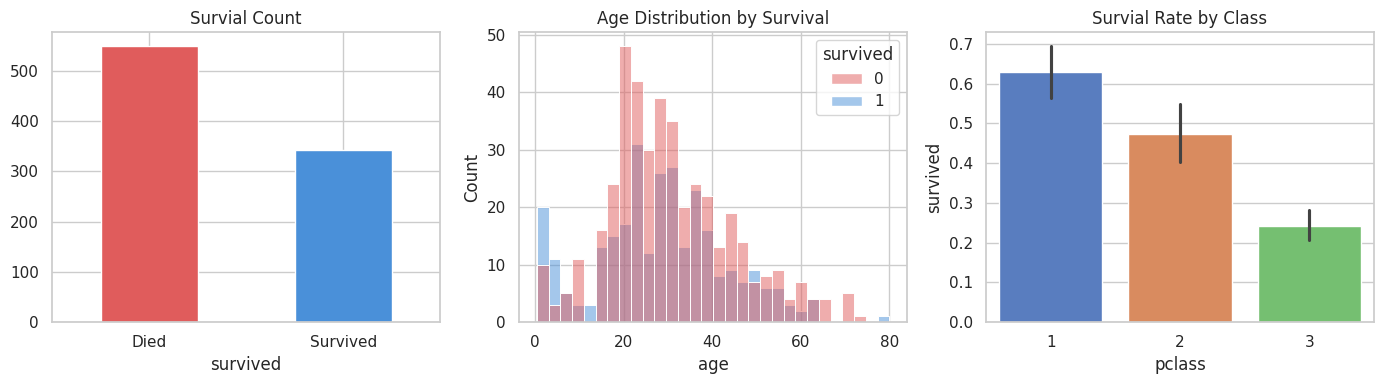

In [6]:
# Titanic Explore

print(titanic_raw.info())
print("\nMissing values:\n", titanic_raw.isnull().sum())
print("\nSurvival rate:", titanic_raw['survived'].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(14,4))

titanic_raw['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e05c5c', '#4a90d9'])
axes[0].set_title('Survial Count')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

sns.histplot(data=titanic_raw, x='age', hue='survived', bins=30, ax=axes[1], palette=['#e05c5c','#4a90d9'])
axes[1].set_title('Age Distribution by Survival')

sns.barplot(data=titanic_raw, x='pclass', y='survived', ax=axes[2], palette='muted')
axes[2].set_title('Survial Rate by Class')

plt.tight_layout()
plt.show()

In [7]:
# Titanic: Preprocessing

df_t = titanic_raw[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

df_t['age'].fillna(df_t['age'].median(), inplace=True)
df_t['fare'].fillna(df_t['fare'].median(), inplace=True)
df_t.dropna(inplace=True)

df_t['sex'] = df_t['sex'].map({'male': 0, 'female': 1})
df_t['embarked'] = df_t['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df_t['family_size'] = df_t['sibsp'] + df_t['parch']
df_t['is_alone'] = (df_t['family_size'] == 0).astype(int)

X_t = df_t.drop('survived', axis=1)
y_t = df_t['survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)

print(f"Train size: {X_train_t.shape}, Test size: {X_test_t.shape}")
print(f"Class balance (train): {y_train_t.value_counts(normalize=True).round(3).to_dict()}")

Train size: (711, 9), Test size: (178, 9)
Class balance (train): {0: 0.617, 1: 0.383}
